Python для инженерии данных
## Домашнее задание 3
### Чанышев Тимур ВШЭ-ИД-1-26

### Задача 1
```
Для каждого покупателя получите таблицу со столбцами:
 • preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
 • total_spent - сумма всех трат;
 • addons_spent - сумма на дополнительные услуги и аксессуары;
 • orders_count - число заказов.

 Отсортируйте по total_spent по убыванию и выведите топ-10.

Пример вывода (формат; числа зависят от датасета):

    customer_id  preferred_payment  total_spent  addons_spent  orders_count
 0    C042          Credit Card        15420.50       890.00             7
 1    C018          PayPal             14810.00       450.00             5
 2    C103          Debit Card         13990.25      1200.00             6
 ...

 Пограничные случаи:
 • Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
 • Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
 • Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
 • Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.
```

In [75]:
import pandas as pd

df = pd.read_csv("../src/Electronic_sales_Sep2023-Sep2024.csv")

df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [76]:
# Делаем row_number для поиска самого частоиспользуемого метода оплаты
# Если количество покупок этим методом одинаково, то выбираем по алфавитному порядку

payment_methods_count_df = (
    df.groupby(
        ["Customer ID", "Payment Method"],
        as_index=False
    )
    .agg(orders_count=("Customer ID", "size"))
    .sort_values(
        ["Customer ID","orders_count", "Payment Method"],
        ascending=[True, False, True]
    )
)

payment_methods_count_df["row_number"] = payment_methods_count_df.groupby("Customer ID").cumcount()

preferred_payment_df = payment_methods_count_df[payment_methods_count_df["row_number"] == 0] # оставляем только строки где row_number = 0

preferred_payment_df.head()

,Customer ID,Payment Method,orders_count,row_number
0,1000,Credit Card,1,0
2,1002,Cash,1,0
4,1003,Cash,1,0
5,1004,Credit Card,1,0
6,1005,Debit Card,1,0


In [77]:
result_df = df.groupby("Customer ID", as_index=False).agg(
    total_spent=("Total Price", "sum"),
    addons_spent=("Add-on Total", "sum"),
    orders_count=("Customer ID", "size")
)

result_df = (
    result_df.merge(
        preferred_payment_df[["Customer ID", "Payment Method"]],
        on="Customer ID",
        how="left"
    )
    .rename(columns={"Payment Method": "preferred_payment"})
    .sort_values("total_spent", ascending=False)
)

# Заполнение пропусков в суммах
# Пропуски в методе оплаты убираются в groupby при формировании preferred_payments
result_df["total_spent"] = result_df["total_spent"].fillna(0)
result_df["addons_spent"] = result_df["addons_spent"].fillna(0)

result_df.head(10).reset_index(drop=True)

,Customer ID,total_spent,addons_spent,orders_count,preferred_payment
0,16357,34563.70,495.19,7,Bank Transfer
1,16863,33035.92,486.17,5,PayPal
2,13813,31830.16,268.64,5,Credit Card
3,11476,31077.61,301.59,5,PayPal
4,12276,30961.18,329.07,6,Bank Transfer
5,13635,30260.36,480.73,5,Credit Card
6,12749,29394.56,619.43,5,Credit Card
7,15399,29084.88,305.39,3,PayPal
8,12319,27352.32,226.38,3,Bank Transfer
9,19996,27296.78,432.12,6,Bank Transfer


Пограничные случаи

- Покупатель с одним заказом получает `orders_count = 1`, а способ оплаты этого заказа становится `preferred_payment`.
- Если несколько способов оплаты использовались одинаковое количество раз, выбирается первый способ по алфавиту.
- Если покупатель не приобретал дополнительные услуги, его `addons_spent` равен `0`.
- Пропуски в `total_spent` и `addons_spent` заменяются на `0`.
- Пропуски в `Payment Method` не учитываются при определении предпочтительного способа оплаты.
- Соединение выполняется через `left join`, поэтому все покупатели сохраняются в итоговой таблице.

### Задача 2
```
Постройте пайплайн на Pandas (без циклов по строкам):

    1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.
    2. Метрики:
        • доход по методу доставки;
        • доход по типу продукта;
        • доход по доп. услугам: по месяцам и по кварталам;
        • cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
    3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.
    4. Выводы: несколько предложений по графикам. (?необязательно)

    Дополнительно: оформите шаги 1–2 как функции clean(df) → df и build_metrics(df) → dict[str, DataFrame].

Пример вывода метрик (фрагменты):

>>> metrics['revenue_by_shipping']
 shipping_method   revenue
 Express           125400.50
 Standard           98320.00
 Pickup             45110.75

 >>> metrics['addons_by_month'].head()
 month      addons_revenue
 2023-01           4200.00
 2023-02           3890.50
 2023-03           5100.00

 >>> metrics['cohort_revenue']  # строки — когорта, столбцы — месяц жизни 0..3
 cohort     0         1         2         3
 2023-01  15200.0   8100.0   4300.0   2100.0
 2023-02  14100.0   7600.0   3900.0      NaN
 ...

Графики: три отдельных figure/axes с подписями осей и заголовками. Числа в примере иллюстративные.

Пограничные случаи:

    • Заказы с отрицательной или нулевой ценой - не должны попадать в доход после clean.
    • Покупатель с одним заказом - в когортной матрице заполнен только месяц 0.
    • Месяц без доп. услуг - в addons_by_month строка с 0 или отсутствие месяца (выберите и зафиксируйте поведение).
    • Пустой датасет после очистки → функции не падают, возвращают пустые таблицы.
```

In [78]:
# Purchase Date нужно преобразовать в date
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  str    
 3   Loyalty Member     20000 non-null  str    
 4   Product Type       20000 non-null  str    
 5   SKU                20000 non-null  str    
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  str    
 8   Payment Method     20000 non-null  str    
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  str    
 13  Shipping Type      20000 non-null  str    
 14  Add-ons Purchased  15132 non-null  str    
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4), str(9)
m

In [79]:
# Пропуски Add-ons Purchased означают отсутствие дополнений
# для метрики используется числовой Add-on Total
df.isna().sum()

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

In [80]:
# Исключить отмененные заказы для расчета дохода
df["Order Status"].value_counts(dropna=False)

Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64

1. Очистка

In [81]:
def clean(df):
    result = df.copy()

    # Преобразуем Purchase Date в datetime
    result["Purchase Date"] = pd.to_datetime(
        result["Purchase Date"],
        errors="coerce"
    )

    # Доход считаем только по завершённым заказам
    result = result[result["Order Status"] == "Completed"]

    # Защита от аномалий
    result["Total Price"] = result["Total Price"].fillna(0)
    result["Add-on Total"] = result["Add-on Total"].fillna(0)

    result = result[
        (result["Total Price"] > 0)
        & (result["Unit Price"] > 0)
        & (result["Quantity"] > 0)
        & (result["Add-on Total"] >= 0)
    ]

    # Убираем строки с некорректной датой
    result = result.dropna(subset=["Purchase Date"])

    return result.reset_index(drop=True)

cleaned_df = clean(df)

cleaned_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13432 entries, 0 to 13431
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        13432 non-null  int64         
 1   Age                13432 non-null  int64         
 2   Gender             13431 non-null  str           
 3   Loyalty Member     13432 non-null  str           
 4   Product Type       13432 non-null  str           
 5   SKU                13432 non-null  str           
 6   Rating             13432 non-null  int64         
 7   Order Status       13432 non-null  str           
 8   Payment Method     13432 non-null  str           
 9   Total Price        13432 non-null  float64       
 10  Unit Price         13432 non-null  float64       
 11  Quantity           13432 non-null  int64         
 12  Purchase Date      13432 non-null  datetime64[us]
 13  Shipping Type      13432 non-null  str           
 14  Add-ons Purchased

2. Метрики

In [82]:
def build_metrics(source_df):

    # Доход по методу доставки
    df = source_df.copy()
    revenue_by_shipping = (
        df
        .groupby("Shipping Type", as_index=False)
        .agg(revenue=("Total Price", "sum"))
        .sort_values("revenue", ascending=False)
        .reset_index(drop=True)
    )

    # Доход по типу продукта
    df = source_df.copy()
    revenue_by_product = (
        df
        .groupby("Product Type", as_index=False)
        .agg(revenue=("Total Price", "sum"))
        .sort_values("revenue", ascending=False)
        .reset_index(drop=True)
    )

    # Доход по доп услугам по месяцам
    df = source_df.copy()
    df["month"] = df["Purchase Date"].dt.to_period("M")
    addons_by_month = (
        df
        .groupby("month", as_index=False)
        .agg(addons_revenue=("Add-on Total", "sum"))
        .sort_values("month", ascending=True)
        .reset_index(drop=True)
    )

    # Доход по доп услугам по кварталам
    df = source_df.copy()
    df["quarter"] = df["Purchase Date"].dt.to_period("Q")
    addons_by_quarter = (
        df
        .groupby("quarter", as_index=False)
        .agg(addons_revenue=("Add-on Total", "sum"))
        .sort_values("quarter", ascending=True)
        .reset_index(drop=True)
    )

    # Когортный анализ
    df = source_df.copy()
    df["order_month"] = df["Purchase Date"].dt.to_period("M")
    df["cohort"] = df.groupby("Customer ID")["order_month"].transform("min")

    ### cколько месяцев прошло между месяцем когорты и месяцем заказа
    df["cohort_month"] = (
        (df["order_month"].dt.year - df["cohort"].dt.year) * 12
        + df["order_month"].dt.month
        - df["cohort"].dt.month
    )

    ### оставляем только первые 4 месяца
    df = df[df["cohort_month"].between(0, 3)]

    # Матрица выручки
    cohort_revenue = (
        df
        .groupby(["cohort", "cohort_month"])["Total Price"]
        .agg("sum")
        .unstack()
        .reindex(columns=range(4))
    )

    # Матрица количества покупателей
    cohort_customers = (
        df
        .groupby(["cohort", "cohort_month"])["Customer ID"]
        .nunique()
        .unstack()
        .reindex(columns=range(4))
    )

    result = {
        "revenue_by_shipping": revenue_by_shipping,
        "revenue_by_product": revenue_by_product,
        "addons_by_month": addons_by_month,
        "addons_by_quarter": addons_by_quarter,
        "cohort_revenue": cohort_revenue,
        "cohort_customers": cohort_customers
    }

    return result

In [83]:
metrics = build_metrics(cleaned_df)

for name, metric_df in metrics.items():
    print(name)
    display(metric_df.head())

revenue_by_shipping


,Shipping Type,revenue
0,Standard,14387037.62
1,Expedited,8430385.58
2,Same Day,8292376.50
3,Overnight,5887722.52
4,Express,5632093.35


revenue_by_product


,Product Type,revenue
0,Smartphone,14407835.84
1,Smartwatch,9398591.23
2,Laptop,8365905.25
3,Tablet,7722632.25
4,Headphones,2734651.00


addons_by_month


...

,quarter,addons_revenue
0,2023Q3,5337.61
1,2023Q4,73356.77
2,2024Q1,258222.60
3,2024Q2,256316.84
4,2024Q3,242361.42


cohort_revenue


cohort_month,0,1,2,3
cohort,,,,
2023-09,283635.75,33456.62,26608.97,33037.33
2023-10,1521869.24,56062.66,104107.36,104115.98
2023-11,1307444.87,50714.25,118382.28,48411.54
2023-12,1122163.93,69367.01,50377.99,64964.23
2024-01,4212120.86,219854.68,355993.76,361010.49


cohort_customers


cohort_month,0,1,2,3
cohort,,,,
2023-09,121.0,11.0,12.0,12.0
2023-10,581.0,27.0,35.0,36.0
2023-11,482.0,21.0,39.0,24.0
2023-12,442.0,27.0,16.0,23.0
2024-01,1236.0,72.0,88.0,88.0


3. Графики

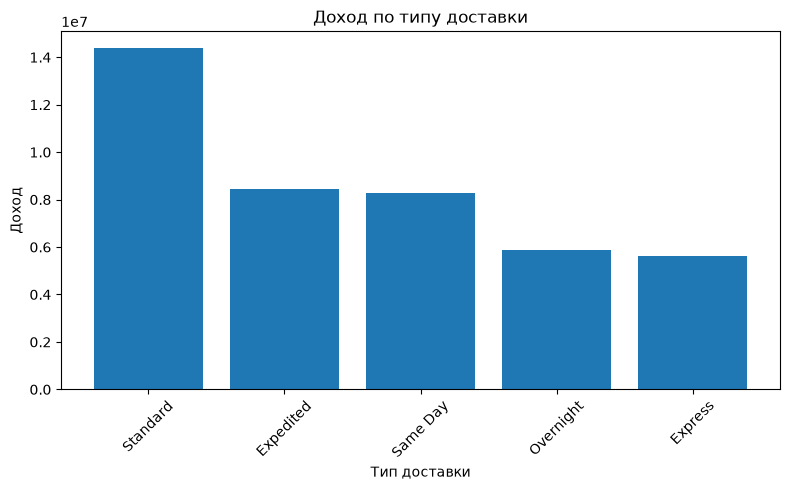

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns


# График дохода по типу доставки
shipping = metrics["revenue_by_shipping"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    shipping["Shipping Type"],
    shipping["revenue"]
)

ax.set_title("Доход по типу доставки")
ax.set_xlabel("Тип доставки")
ax.set_ylabel("Доход")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

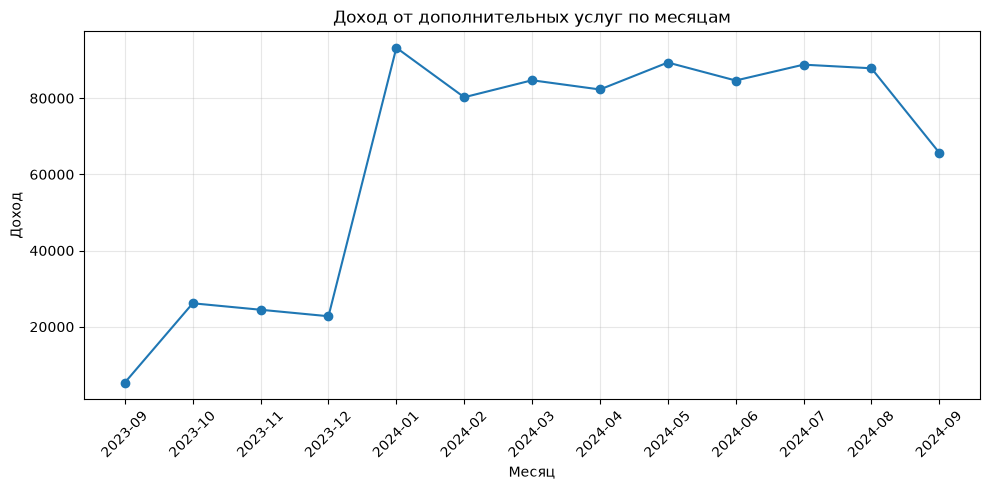

In [85]:
# График дохода от доп услуг по типу месяцам
addons_month = (
    metrics["addons_by_month"]
    .sort_values("month")
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    addons_month["month"].astype(str),
    addons_month["addons_revenue"],
    marker="o"
)

ax.set_title("Доход от дополнительных услуг по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Доход")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

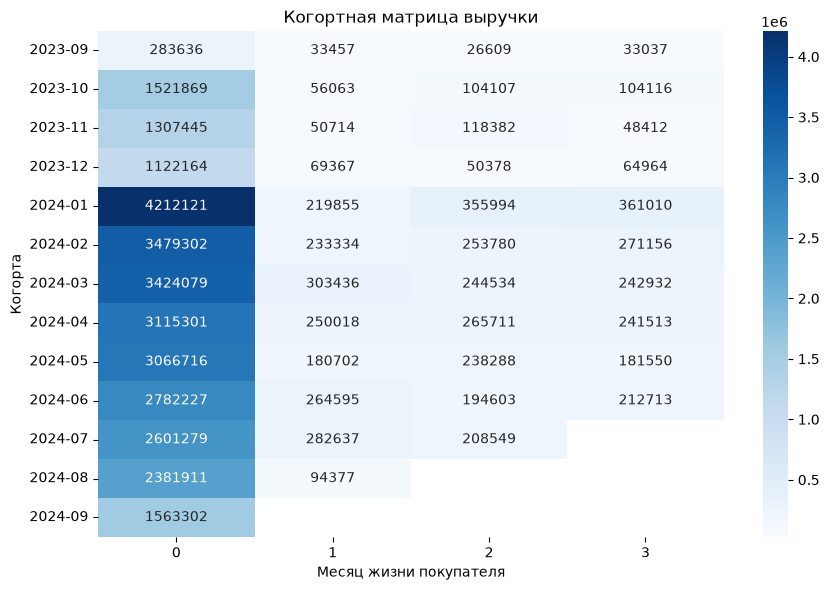

In [86]:
# Тепловая карта когортной выручки
cohort_revenue = metrics["cohort_revenue"]

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    cohort_revenue,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    ax=ax
)

ax.set_title("Когортная матрица выручки")
ax.set_xlabel("Месяц жизни покупателя")
ax.set_ylabel("Когорта")

plt.tight_layout()
plt.show()

Пограничные случаи:

- Заказы с нулевой или отрицательной ценой исключаются в функции `clean()`. Также исключаются строки с нулевым количеством товара и отрицательной стоимостью дополнительных услуг.
- Отменённые заказы не учитываются при расчёте дохода.
- Некорректные даты преобразуются в `NaT`, после чего такие строки удаляются.
- Для покупателя с одним заказом когорта совпадает с месяцем заказа. Данные будут только в месяце жизни `0`, а месяцы `1–3` останутся пустыми (`NaN`).
- Если в месяце были заказы, но не было дохода от дополнительных услуг, сумма будет равна `0`. Месяцы без завершённых заказов в таблицу не включаются.
- Если после очистки DataFrame окажется пустым, функции возвращают пустые таблицы и не вызывают ошибку.
- Пропуски в `Add-ons Purchased` означают отсутствие дополнений. Для расчёта используется числовой столбец `Add-on Total`.